# Uber Trips Analysis using Python

## تحليل رحلات Uber باستخدام لغة Python


## 1. المقدمة (Introduction)

يهدف هذا المشروع إلى تحليل بيانات رحلات Uber باستخدام لغة Python، وذلك لاكتشاف الأنماط المختلفة للرحلات وتحليلها من حيث الأيام والساعات والأشهر، بالإضافة إلى تحديد أوقات الذروة والأيام الأكثر ازدحامًا.

يساعد تحليل هذه البيانات على فهم سلوك الطلب على خدمات Uber واستخراج معلومات يمكن الاستفادة منها في تحسين إدارة الرحلات وتوزيع الموارد.


### الخطوة الأولى: استيراد مكتبات Python اللازمة

في هذه الخطوة سيتم استيراد المكتبات الأساسية المستخدمة في تحليل البيانات ومعالجتها وإنشاء الرسوم البيانية، وهي مكتبات Pandas وMatplotlib وSeaborn.
###   تحميل مجموعة البيانات (Load Dataset)

في هذه الخطوة سيتم تحميل ملف `uber.csv` باستخدام مكتبة Pandas وتخزين البيانات في DataFrame باسم `data`.


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
data = pd.read_csv()
data["Date/Time"] = data["Date/Time"].map(pd.to_datetime)
data.head()

ParserError: Error tokenizing data. C error: EOF inside string starting at row 68582

### الخطوة الثانية: فحص البيانات (Data Inspection)

بعد تحميل البيانات، سيتم فحص مجموعة البيانات للتعرف على عدد السجلات والأعمدة وأنواع المتغيرات والقيم المفقودة.

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("/content/uber-raw-data-sep14.csv")

data["Date/Time"] = pd.to_datetime(data["Date/Time"])

data.head()

,Date/Time,Lat,Lon,Base
0,2014-09-01 00:01:00,40.2201,-74.0021,B02512
1,2014-09-01 00:01:00,40.7500,-74.0027,B02512
2,2014-09-01 00:03:00,40.7559,-73.9864,B02512
3,2014-09-01 00:06:00,40.7450,-73.9889,B02512
4,2014-09-01 00:11:00,40.8145,-73.9444,B02512


In [ ]:
print("Shape of dataset:", data.shape)

print("\nDataset information:")
data.info()

print("\nMissing values:")
print(data.isnull().sum())

Shape of dataset: (1028136, 7)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1028136 entries, 0 to 1028135
Data columns (total 7 columns):
 #   Column     Non-Null Count    Dtype         
---  ------     --------------    -----         
 0   Date/Time  1028136 non-null  datetime64[ns]
 1   Lat        1028136 non-null  float64       
 2   Lon        1028136 non-null  float64       
 3   Base       1028136 non-null  object        
 4   Day        1028136 non-null  int64         
 5   Weekday    1028136 non-null  int64         
 6   Hour       1028136 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(3), object(1)
memory usage: 54.9+ MB

Missing values:
Date/Time    0
Lat          0
Lon          0
Base         0
Day          0
Weekday      0
Hour         0
dtype: int64


## استخراج المتغيرات الزمنية

سيتم استخراج اليوم، ويوم الأسبوع، والساعة من عمود `Date/Time` لاستخدامها في تحليل أنماط رحلات Uber.

In [ ]:
data["Day"] = data["Date/Time"].apply(lambda x: x.day)
data["Weekday"] = data["Date/Time"].apply(lambda x: x.weekday())
data["Hour"] = data["Date/Time"].apply(lambda x: x.hour)
print(data.head())

            Date/Time      Lat      Lon    Base  Day  Weekday  Hour
0 2014-09-01 00:01:00  40.2201 -74.0021  B02512    1        0     0
1 2014-09-01 00:01:00  40.7500 -74.0027  B02512    1        0     0
2 2014-09-01 00:03:00  40.7559 -73.9864  B02512    1        0     0
3 2014-09-01 00:06:00  40.7450 -73.9889  B02512    1        0     0
4 2014-09-01 00:11:00  40.8145 -73.9444  B02512    1        0     0


## توزيع رحلات Uber حسب اليوم

يوضح الرسم البياني توزيع عدد الرحلات حسب أيام الشهر، مما يساعد على معرفة الأيام الأكثر ازدحامًا بالرحلات.

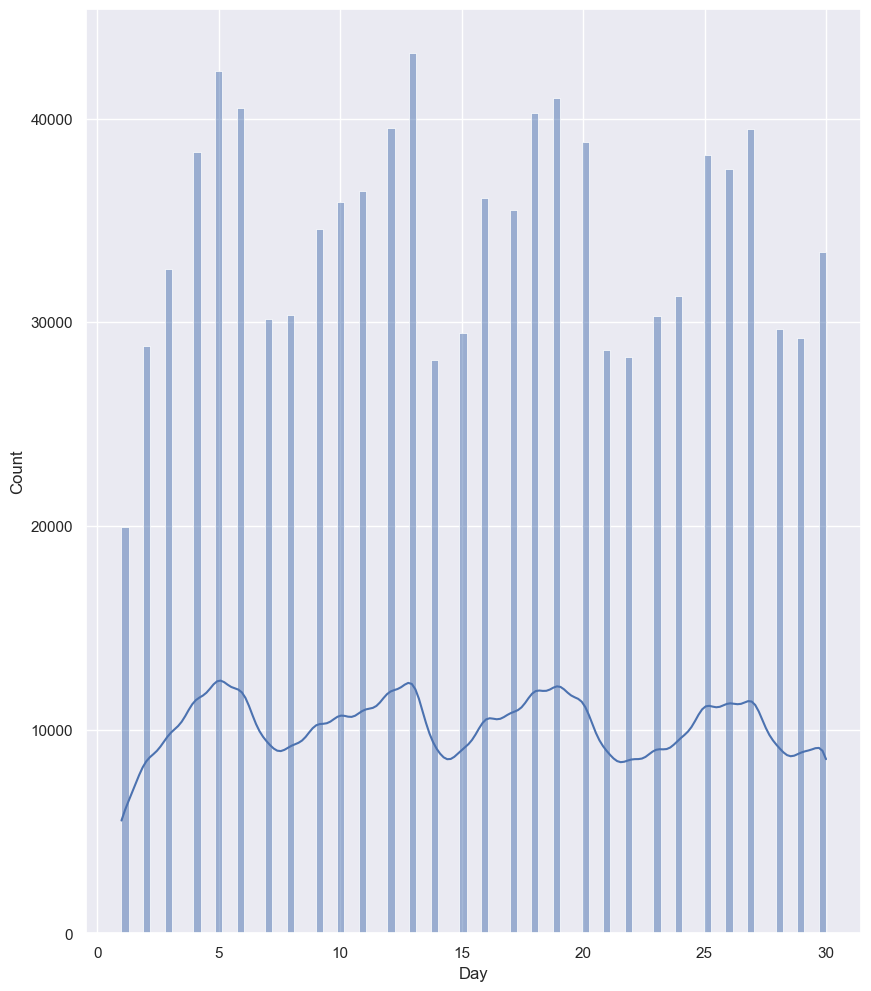

In [ ]:
sns.set(rc={'figure.figsize': (10, 12)})
sns.histplot(data["Day"], kde=True)
plt.show()

## توزيع رحلات Uber حسب الساعة

يوضح الرسم البياني عدد رحلات Uber خلال ساعات اليوم، مما يساعد على تحديد ساعات الذروة.

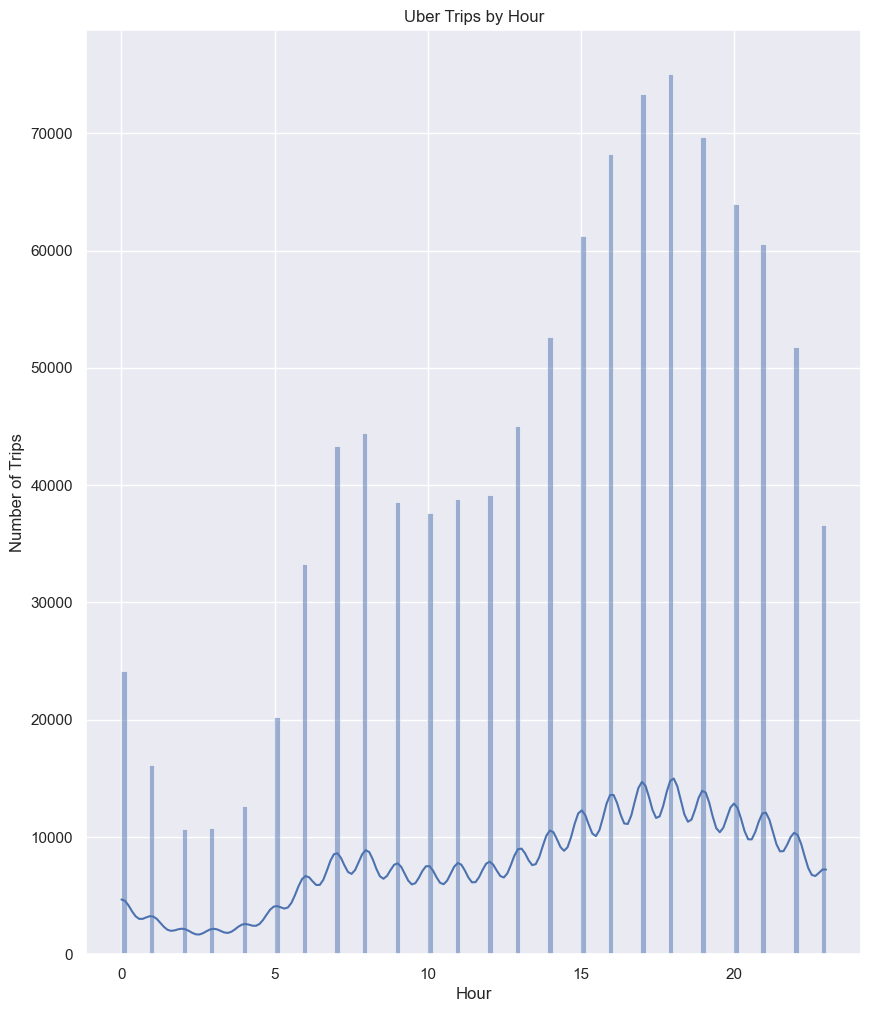

In [ ]:
sns.histplot(data["Hour"], kde=True)
plt.xlabel("Hour")
plt.ylabel("Number of Trips")
plt.title("Uber Trips by Hour")
plt.show()

## توزيع رحلات Uber حسب يوم الأسبوع

يوضح الرسم البياني توزيع الرحلات حسب أيام الأسبوع، مما يساعد على معرفة الأيام الأكثر ازدحامًا.

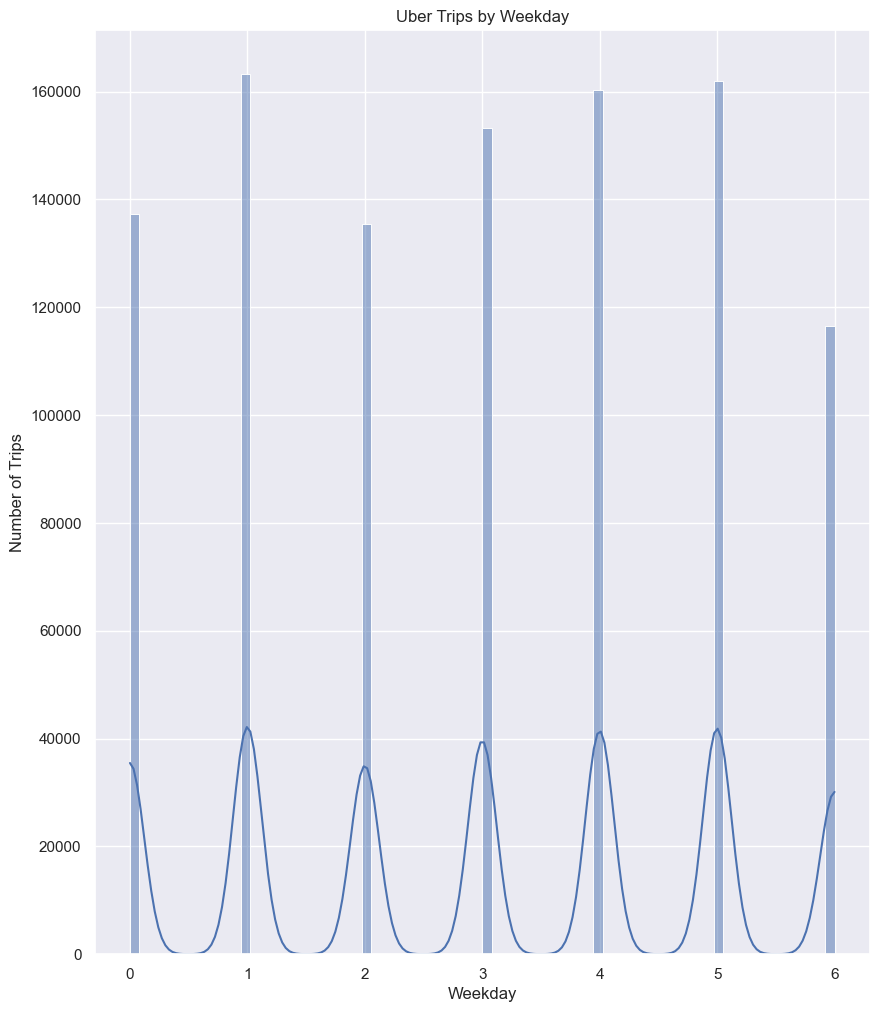

In [ ]:
sns.histplot(data["Weekday"], kde=True)
plt.xlabel("Weekday")
plt.ylabel("Number of Trips")
plt.title("Uber Trips by Weekday")
plt.show()

## Correlation of Weekday and Hour

يُستخدم هذا التحليل لمعرفة العلاقة بين يوم الأسبوع وساعة الرحلة، وتحديد الأوقات التي يزداد فيها عدد رحلات Uber.

C:\Users\ameer\AppData\Local\Temp\ipykernel_39640\3056824601.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = data.groupby(["Weekday", "Hour"]).apply(lambda x: len(x))


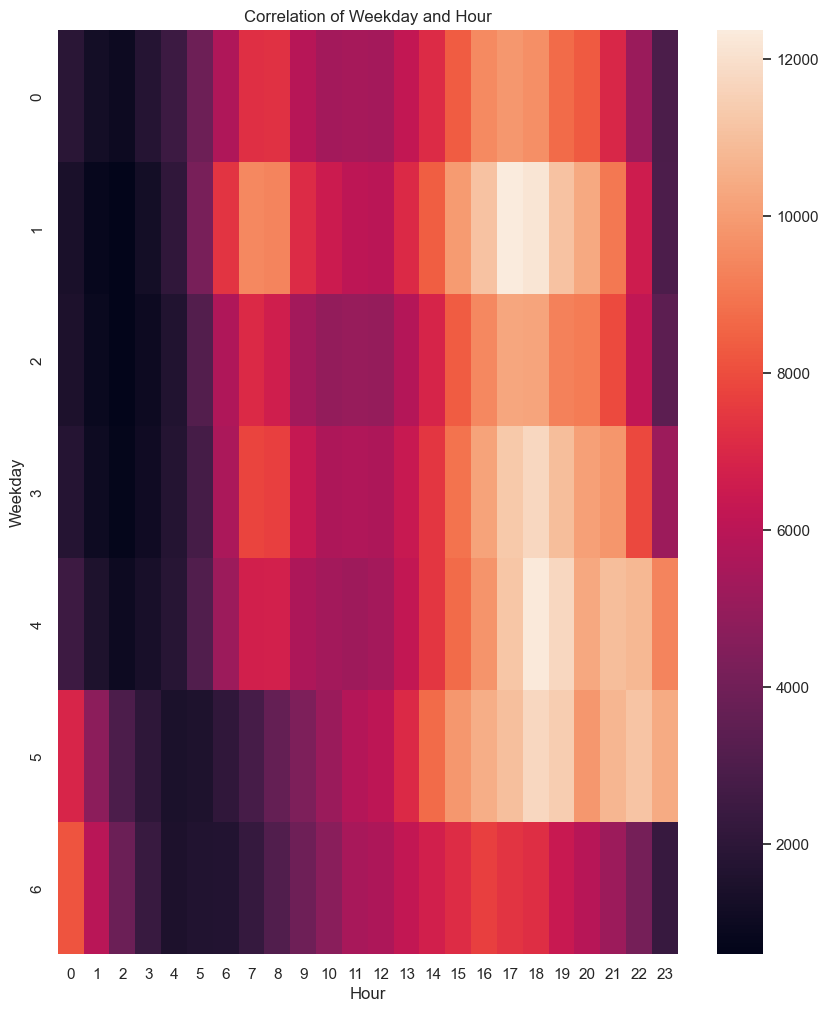

In [ ]:
df = data.groupby(["Weekday", "Hour"]).apply(lambda x: len(x))
df = df.unstack()

sns.heatmap(df, annot=False)
plt.xlabel("Hour")
plt.ylabel("Weekday")
plt.title("Correlation of Weekday and Hour")
plt.show()

## Geographic Analysis of Uber Trips

يوضح الرسم التوزيع الجغرافي لمواقع رحلات Uber باستخدام خطوط الطول والعرض، مع استخدام حجم النقاط لتمثيل يوم الرحلة.

C:\Users\ameer\anaconda3\Lib\site-packages\pandas\plotting\_matplotlib\core.py:1351: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(


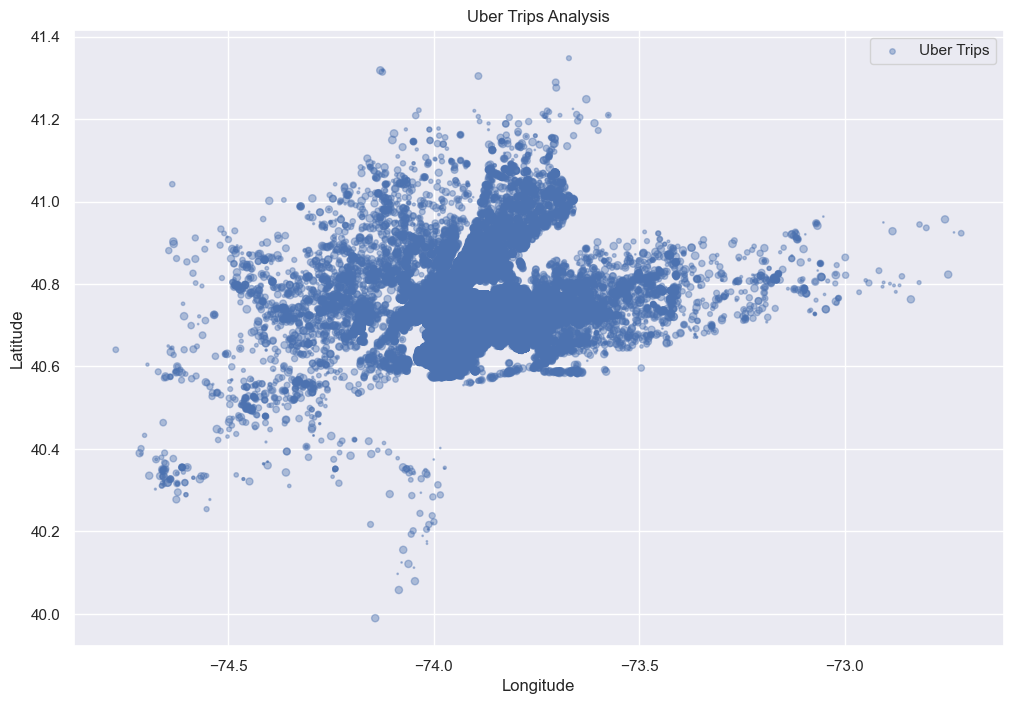

In [ ]:
s=data['Day'], label='Uber Trips',
figsize=(12, 8), cmap=plt.get_cmap('jet'))
plt.title("Uber Trips Analysis")
plt.legend()
plt.show()

## نتائج تحليل رحلات Uber

أظهرت نتائج التحليل مجموعة من الملاحظات المهمة، منها:

- يوم **الاثنين** يُعد من أكثر الأيام نشاطًا في عدد الرحلات.
- تزداد الرحلات بشكل ملحوظ خلال **ساعات المساء**.
- تبدأ زيادة عدد الرحلات في الصباح حوالي الساعة **5 صباحًا**.
- يتركز جزء كبير من رحلات Uber في **منطقة مانهاتن في نيويورك**.
- يوضح التحليل اختلاف عدد الرحلات حسب **اليوم والساعة**، مما يساعد على تحديد أوقات الذروة.